In [32]:
import pandas as pd
import numpy as np
from datetime import datetime
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Prepare Data

In [36]:
df = pd.read_csv('marketing_campaign.csv',sep=';')

In [28]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,TotalSpend
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,0,0,0,0,0,3,11,0,1341
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,0,0,1,0,0,3,11,0,444
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,1,0,0,0,0,3,11,0,1241
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,0,0,0,0,0,3,11,0,843


In [21]:
print(df[['Z_CostContact', 'Z_Revenue']].nunique())

Z_CostContact    1
Z_Revenue        1
dtype: int64


In [29]:
X.dtypes

Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Complain                 int64
dtype: object

In [37]:
# ── 1. FEATURE ENGINEERING ───────────────────────────────────────────────────

# Convert Dt_Customer to tenure in days
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='mixed', dayfirst=True)
reference_date = df['Dt_Customer'].max()
df['Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days
df = df.drop(columns=['Dt_Customer'])

# Age from Year_Birth
df['Age'] = datetime.now().year - df['Year_Birth']
df = df.drop(columns=['Year_Birth'])

# Simplify Marital_Status into binary (partner or not)
df['Has_Partner'] = df['Marital_Status'].isin(['Married', 'Together']).astype(int)
df = df.drop(columns=['Marital_Status'])

# Simplify Education into ordinal levels
education_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']

In [40]:
# Dropping columns that could harm model performance:
# - AcceptedCmp1-5: risk of data leakage (collected same time as target)
# - TotalSpend: redundant, it's just a sum of the Mnt* columns
# - Z_CostContact, Z_Revenue: constant values, zero variance
# - ID: identifier, carries no predictive signal
drop_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
             'AcceptedCmp4', 'AcceptedCmp5',
             'Z_CostContact', 'Z_Revenue', 'ID']

X = df.drop(columns=drop_cols + ['Response'])
y = df['Response']

categorical_features = ['Education']
numerical_features = [c for c in X.columns if c not in categorical_features]

In [41]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=[education_order],
                                   handle_unknown='use_encoded_value',
                                   unknown_value=-1))
    ]), categorical_features)
])


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Class imbalance ratio for tree-based models
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


# Find best model

In [57]:
def objective_xgb(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 100, 600),
        'max_depth':          trial.suggest_int('max_depth', 3, 10),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight':   scale_pos_weight,
        'eval_metric':        'aucpr',  # changed to PR-AUC
        'use_label_encoder':  False,
        'random_state':       42,
        'n_jobs':             -1
    }
    model = Pipeline([('pre', preprocessor),
                      ('clf', XGBClassifier(**params))])
    return cross_val_score(model, X_train, y_train,
                           cv=cv, scoring='average_precision', n_jobs=-1).mean()


def objective_lgbm(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'class_weight':     'balanced',
        'random_state':     42,
        'n_jobs':           1,
        'verbose':          -1,
        'force_col_wise':   True
    }
    model = Pipeline([('pre', preprocessor),
                      ('clf', LGBMClassifier(**params))])
    return cross_val_score(model, X_train, y_train,
                           cv=cv, scoring='average_precision', n_jobs=1).mean()


def objective_cat(trial):
    params = {
        'iterations':         trial.suggest_int('iterations', 100, 600),
        'depth':              trial.suggest_int('depth', 3, 10),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':        trial.suggest_float('l2_leaf_reg', 1e-4, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'scale_pos_weight':   scale_pos_weight,
        'random_seed':        42,
        'verbose':            False
    }
    cat_idx = [X_train.columns.get_loc('Education')]
    model = CatBoostClassifier(**params, cat_features=cat_idx)
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='average_precision', n_jobs=-1)
    return scores.mean()


def objective_lr(trial):
    params = {
        'C':            trial.suggest_float('C', 1e-3, 10.0, log=True),
        'penalty':      trial.suggest_categorical('penalty', ['l1', 'l2']),
        'class_weight': 'balanced',
        'solver':       'saga',
        'max_iter':     2000,
        'random_state': 42
    }
    model = Pipeline([('pre', preprocessor),
                      ('clf', LogisticRegression(**params))])
    return cross_val_score(model, X_train, y_train,
                           cv=cv, scoring='average_precision', n_jobs=-1).mean()


def objective_svm(trial):
    params = {
        'C':            trial.suggest_float('C', 1e-2, 100.0, log=True),
        'gamma':        trial.suggest_categorical('gamma', ['scale', 'auto']),
        'kernel':       trial.suggest_categorical('kernel', ['rbf', 'poly']),
        'class_weight': 'balanced',
        'probability':  True,
        'random_state': 42
    }
    model = Pipeline([('pre', preprocessor),
                      ('clf', SVC(**params))])
    return cross_val_score(model, X_train, y_train,
                           cv=cv, scoring='average_precision', n_jobs=-1).mean()


def objective_mlp(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers = tuple(trial.suggest_int(f'n_units_l{i}', 32, 256) for i in range(n_layers))
    params = {
        'hidden_layer_sizes': layers,
        'activation':         trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha':              trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'max_iter':           500,
        'random_state':       42
    }
    model = Pipeline([('pre', preprocessor),
                      ('clf', MLPClassifier(**params))])
    return cross_val_score(model, X_train, y_train,
                           cv=cv, scoring='average_precision', n_jobs=-1).mean()

In [58]:
studies = {
    'XGBoost':            objective_xgb,
    'LightGBM':           objective_lgbm,
    'CatBoost':           objective_cat,
    'LogisticRegression': objective_lr,
    'SVM':                objective_svm,
    'MLP':                objective_mlp,
}
best_params = {}
results = {}

for name, objective in studies.items():
    print(f"\n── Tuning {name} ──")
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=50, show_progress_bar=True)
    best_params[name] = study.best_params
    results[name] = study.best_value
    print(f"  Best PR-AUC: {study.best_value:.4f}")


── Tuning XGBoost ──


  0%|          | 0/50 [00:00<?, ?it/s]

/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:21:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:21:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:21:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:21:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use

  Best PR-AUC: 0.5961

── Tuning LightGBM ──


  0%|          | 0/50 [00:00<?, ?it/s]

...

  Best PR-AUC: 0.5564

── Tuning MLP ──


  0%|          | 0/50 [00:00<?, ?it/s]

/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691:

  Best PR-AUC: 0.5691


/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691:

In [59]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['CV PR-AUC'])
results_df = results_df.sort_values('CV PR-AUC', ascending=False)
print("\n── CV Results Summary ──")
print(results_df.round(4))


── CV Results Summary ──
                    CV PR-AUC
LightGBM               0.6016
XGBoost                0.5961
CatBoost               0.5939
MLP                    0.5691
SVM                    0.5564
LogisticRegression     0.5174


# Test best model

Test ROC-AUC : 0.8879
Test PR-AUC  : 0.5701

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       381
           1       0.45      0.76      0.57        67

    accuracy                           0.83       448
   macro avg       0.70      0.80      0.73       448
weighted avg       0.88      0.83      0.84       448



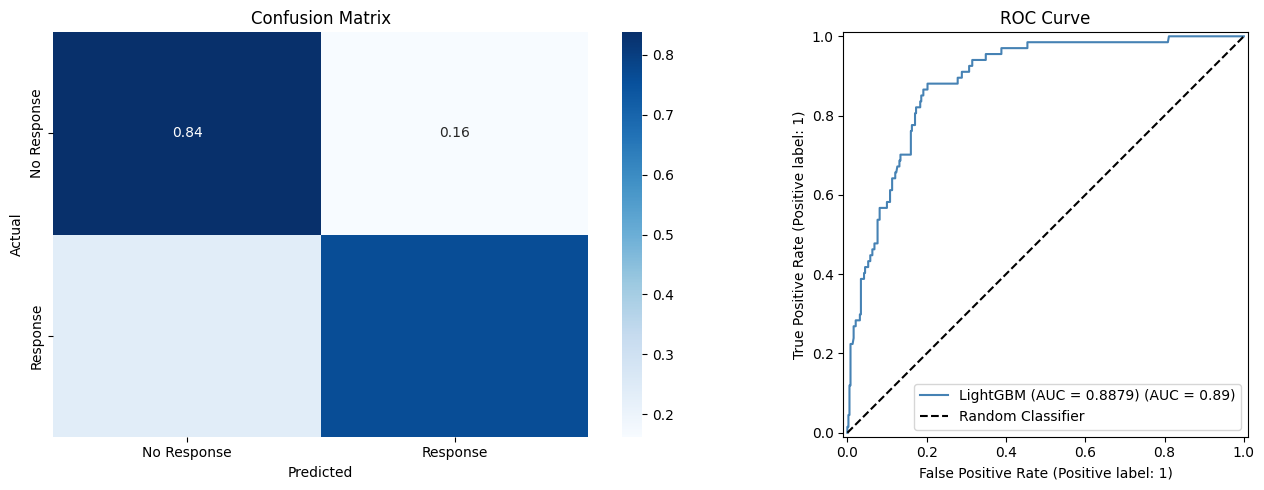

In [60]:
# ── 1. RETRAIN LGBM WITH BEST PARAMS ON FULL TRAIN SET ───────────────────────

best_lgbm = LGBMClassifier(
    **best_params['LightGBM'],
    class_weight='balanced',
    random_state=42,
    n_jobs=1,
    verbose=-1,
    force_col_wise=True
)

final_model = Pipeline([('pre', preprocessor),
                        ('clf', best_lgbm)])

final_model.fit(X_train, y_train)

# ── 2. PREDICT ────────────────────────────────────────────────────────────────

y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = final_model.predict(X_test)

# ── 3. METRICS ────────────────────────────────────────────────────────────────

from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc  = average_precision_score(y_test, y_pred_proba)
print(f"Test ROC-AUC : {roc_auc:.4f}")
print(f"Test PR-AUC  : {pr_auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# ── 4. PLOTS ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=['No Response', 'Response'],
            yticklabels=['No Response', 'Response'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1],
                                  name=f'LightGBM (AUC = {roc_auc:.4f})',
                                  color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

# SHAP Exaplainer

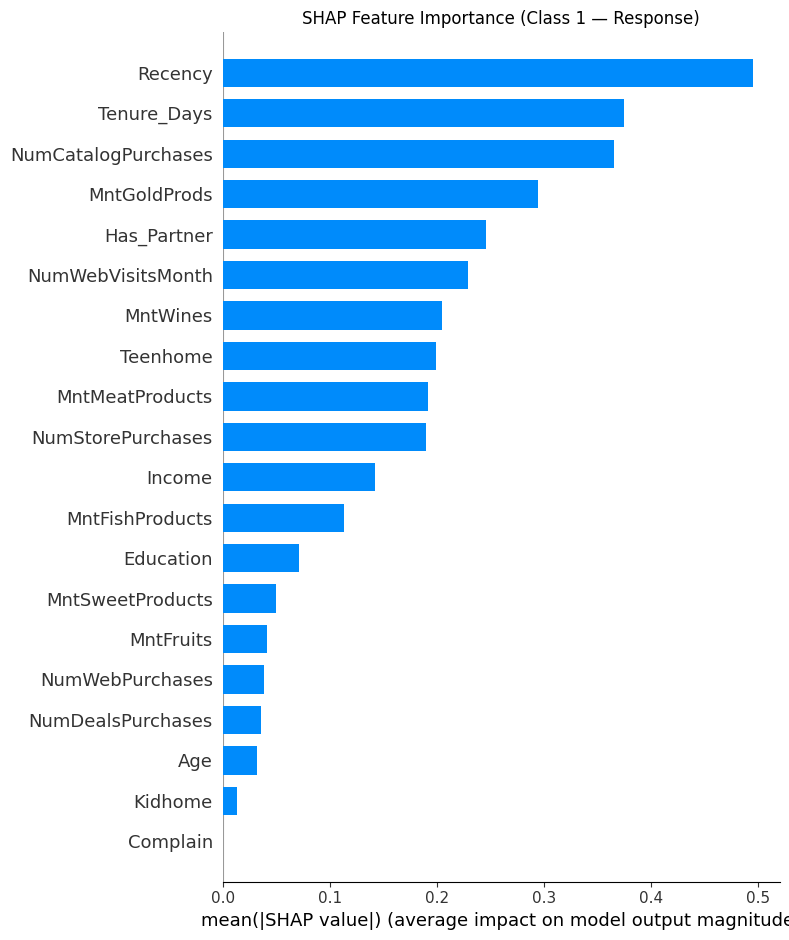

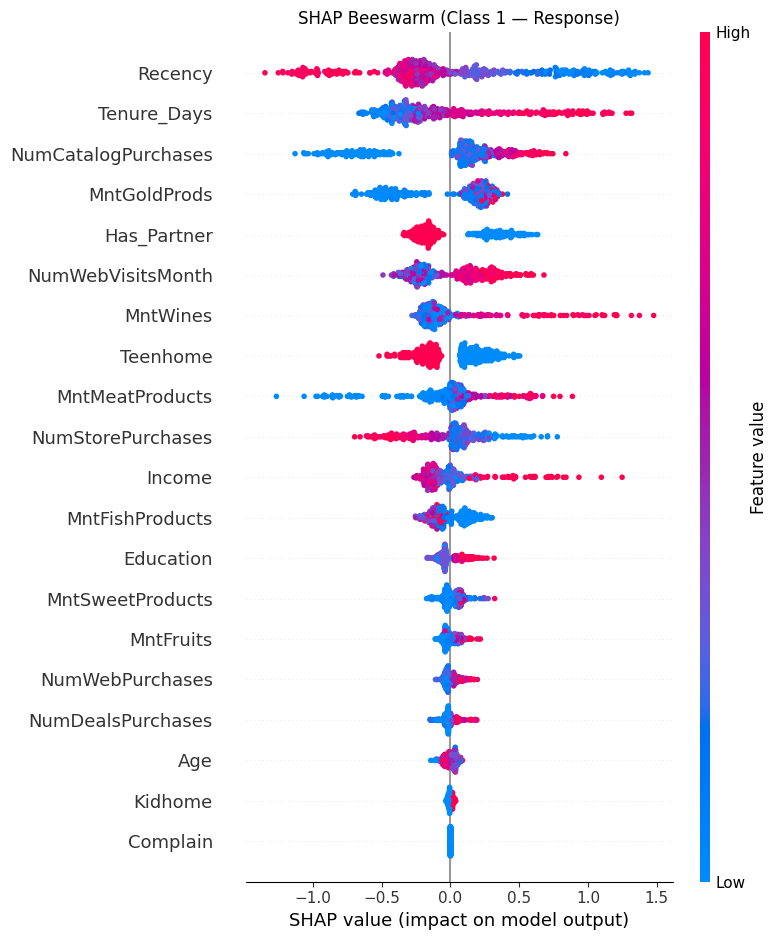

In [61]:
import shap

# ── 1. EXTRACT FITTED LGBM FROM PIPELINE ─────────────────────────────────────

fitted_preprocessor = final_model.named_steps['pre']
fitted_lgbm = final_model.named_steps['clf']

# Transform data for SHAP
X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed  = fitted_preprocessor.transform(X_test)

# Rebuild feature names after preprocessing
feature_names = numerical_features + categorical_features
X_train_shap = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_shap  = pd.DataFrame(X_test_transformed,  columns=feature_names)

# ── 2. SHAP EXPLAINER ─────────────────────────────────────────────────────────

explainer   = shap.TreeExplainer(fitted_lgbm)
shap_values = explainer.shap_values(X_test_shap)

# For binary classification LGBM returns list [class0, class1] — take class 1
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

# ── 3. PLOTS ──────────────────────────────────────────────────────────────────

# Summary bar — global feature importance
plt.figure()
shap.summary_plot(shap_vals, X_test_shap, plot_type='bar',
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Feature Importance (Class 1 — Response)')
plt.tight_layout()
plt.show()

# Beeswarm — shows direction and magnitude of each feature's effect
plt.figure()
shap.summary_plot(shap_vals, X_test_shap,
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Beeswarm (Class 1 — Response)')
plt.tight_layout()
plt.show()

# Insights 

## High Conversion Plots

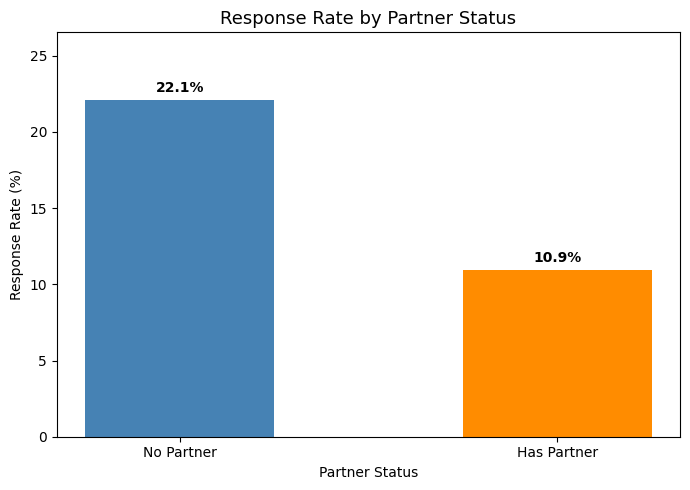

In [62]:
fig, ax = plt.subplots(figsize=(7, 5))

partner_response = df.groupby('Has_Partner')['Response'].mean() * 100

bars = ax.bar(
    ['No Partner', 'Has Partner'],
    partner_response.values,
    color=['steelblue', 'darkorange'],
    width=0.5
)

# Add value labels on top of bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Response Rate by Partner Status', fontsize=13)
ax.set_ylabel('Response Rate (%)')
ax.set_xlabel('Partner Status')
ax.set_ylim(0, partner_response.max() * 1.2)

plt.tight_layout()
plt.show()

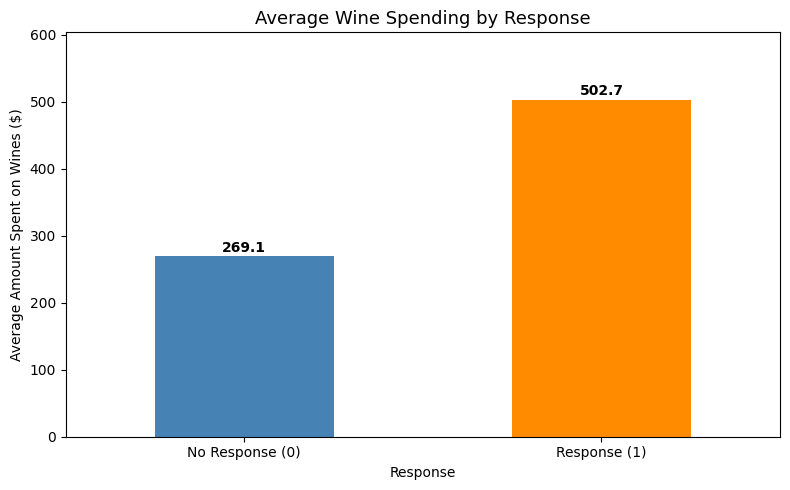

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))

df.groupby('Response')['MntWines'].mean().plot(
    kind='bar',
    color=['steelblue', 'darkorange'],
    width=0.5,
    ax=ax
)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Average Wine Spending by Response', fontsize=13)
ax.set_ylabel('Average Amount Spent on Wines ($)')
ax.set_xlabel('Response')
ax.set_xticklabels(['No Response (0)', 'Response (1)'], rotation=0)
ax.set_ylim(0, df.groupby('Response')['MntWines'].mean().max() * 1.2)

plt.tight_layout()
plt.show()

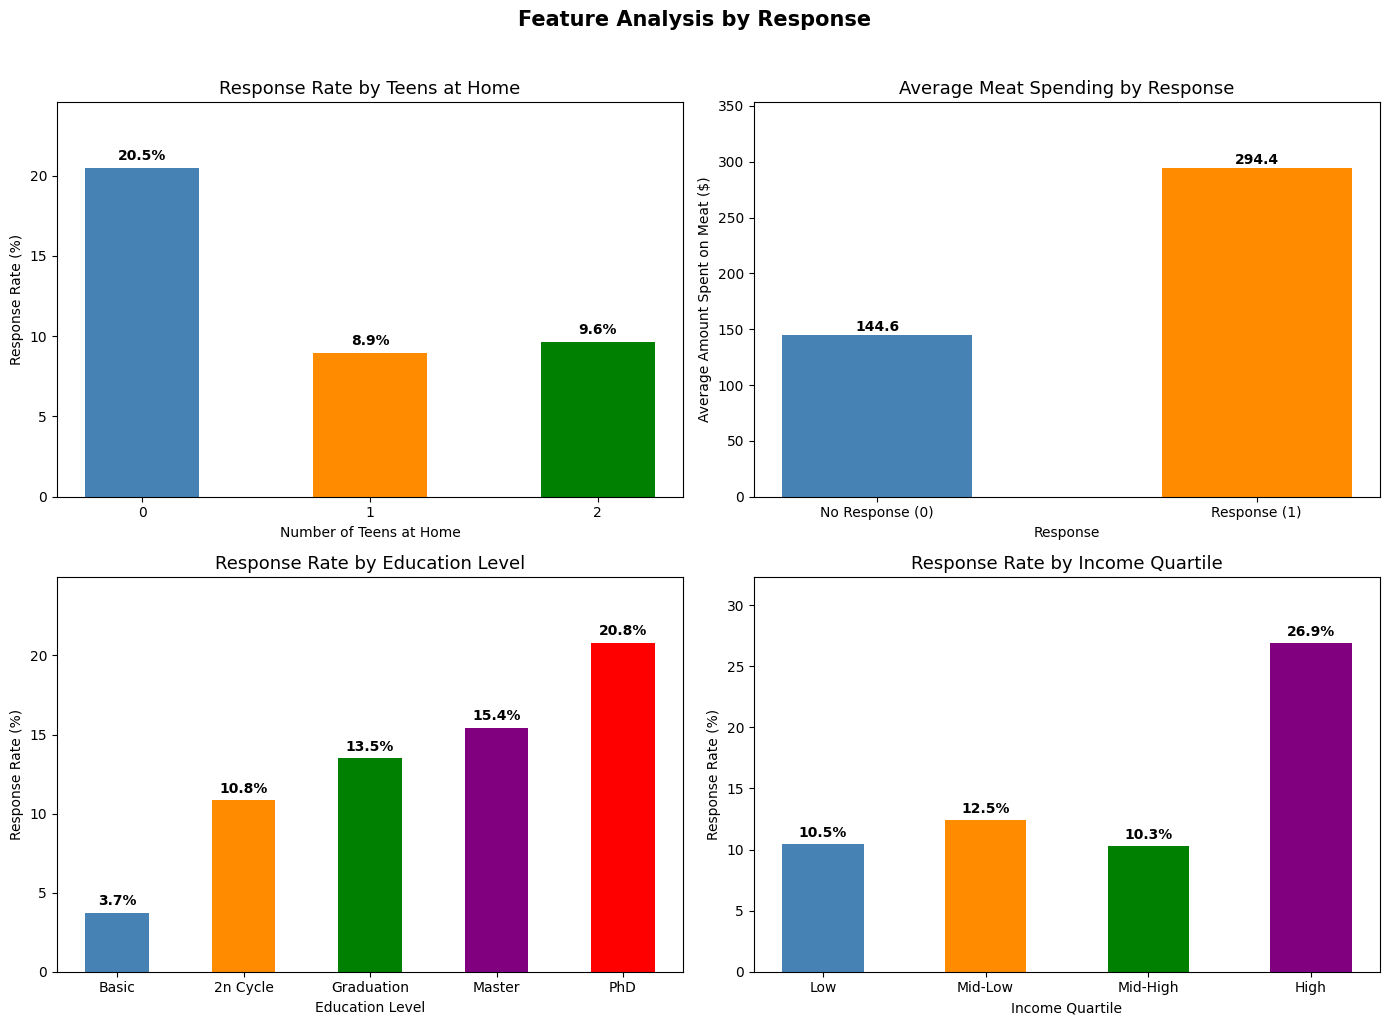

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Teenhome ──────────────────────────────────────────────────────────────────
teen_response = df.groupby('Teenhome')['Response'].mean() * 100
axes[0, 0].bar(teen_response.index.astype(str), teen_response.values,
               color=['steelblue', 'darkorange', 'green'], width=0.5)
for i, v in enumerate(teen_response.values):
    axes[0, 0].text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0, 0].set_title('Response Rate by Teens at Home', fontsize=13)
axes[0, 0].set_ylabel('Response Rate (%)')
axes[0, 0].set_xlabel('Number of Teens at Home')
axes[0, 0].set_ylim(0, teen_response.max() * 1.2)

# ── MntMeatProducts ───────────────────────────────────────────────────────────
meat_response = df.groupby('Response')['MntMeatProducts'].mean()
axes[0, 1].bar(['No Response (0)', 'Response (1)'], meat_response.values,
               color=['steelblue', 'darkorange'], width=0.5)
for i, v in enumerate(meat_response.values):
    axes[0, 1].text(i, v + 1, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')
axes[0, 1].set_title('Average Meat Spending by Response', fontsize=13)
axes[0, 1].set_ylabel('Average Amount Spent on Meat ($)')
axes[0, 1].set_xlabel('Response')
axes[0, 1].set_ylim(0, meat_response.max() * 1.2)

# ── Education ─────────────────────────────────────────────────────────────────
edu_response = df.groupby('Education')['Response'].mean() * 100
edu_response = edu_response.reindex(['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD'])
axes[1, 0].bar(edu_response.index, edu_response.values,
               color=['steelblue', 'darkorange', 'green', 'purple', 'red'], width=0.5)
for i, v in enumerate(edu_response.values):
    axes[1, 0].text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1, 0].set_title('Response Rate by Education Level', fontsize=13)
axes[1, 0].set_ylabel('Response Rate (%)')
axes[1, 0].set_xlabel('Education Level')
axes[1, 0].set_ylim(0, edu_response.max() * 1.2)

# ── Income ────────────────────────────────────────────────────────────────────
df['Income_Bin'] = pd.qcut(df['Income'].dropna(), q=4,
                            labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
income_response = df.groupby('Income_Bin', observed=True)['Response'].mean() * 100
axes[1, 1].bar(income_response.index.astype(str), income_response.values,
               color=['steelblue', 'darkorange', 'green', 'purple'], width=0.5)
for i, v in enumerate(income_response.values):
    axes[1, 1].text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1, 1].set_title('Response Rate by Income Quartile', fontsize=13)
axes[1, 1].set_ylabel('Response Rate (%)')
axes[1, 1].set_xlabel('Income Quartile')
axes[1, 1].set_ylim(0, income_response.max() * 1.2)

plt.suptitle('Feature Analysis by Response', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Bottomline: The marketing conversion was higher for singles that have high income and high education, which correlate with high wine and meat consume and no teenagers at home. These customers already search for the product and don't need much more marketing for conversions.

# Search for persuables

              N_Customers Actual_Response  Avg_Score  Avg_Income  \
segment                                                            
Lost Causes          1399            0.4%      0.115   47974.144   
Persuadables          541           15.9%      0.480   57128.818   
Sure Things           300           80.7%      0.818   63151.297   

              Avg_MntWines  Avg_MntMeat  
segment                                  
Lost Causes        202.588      108.139  
Persuadables       423.124      226.159  
Sure Things        561.617      334.433  


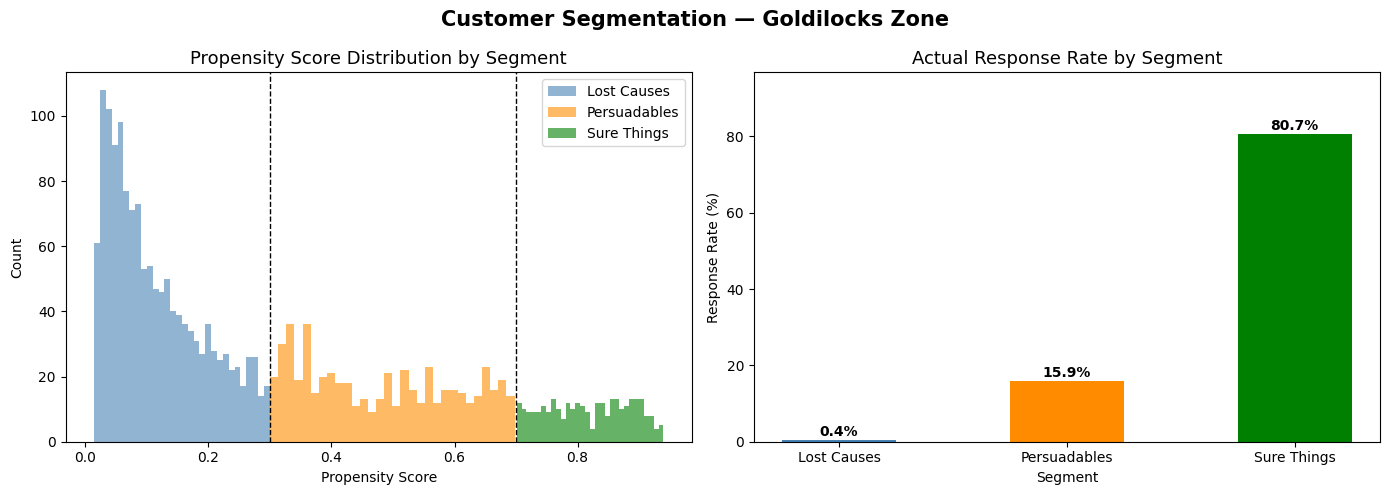

In [67]:
# ── 1. GET PROPENSITY SCORES FOR FULL DATASET ─────────────────────────────────

df['propensity_score'] = final_model.predict_proba(X)[:, 1]

# ── 2. SEGMENT INTO ZONES ─────────────────────────────────────────────────────

def assign_zone(score):
    if score < 0.3:
        return 'Lost Causes'
    elif score <= 0.7:
        return 'Persuadables'
    else:
        return 'Sure Things'

df['segment'] = df['propensity_score'].apply(assign_zone)

# ── 3. SUMMARY TABLE ──────────────────────────────────────────────────────────

summary = df.groupby('segment').agg(
    N_Customers      = ('propensity_score', 'count'),
    Actual_Response  = ('Response', 'mean'),
    Avg_Score        = ('propensity_score', 'mean'),
    Avg_Income       = ('Income', 'mean'),
    Avg_MntWines     = ('MntWines', 'mean'),
    Avg_MntMeat      = ('MntMeatProducts', 'mean'),
).round(3)

summary['Actual_Response'] = (summary['Actual_Response'] * 100).map('{:.1f}%'.format)
summary = summary.loc[['Lost Causes', 'Persuadables', 'Sure Things']]
print(summary)

# ── 4. PLOT ───────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Propensity score distribution colored by segment
colors = {'Lost Causes': 'steelblue', 'Persuadables': 'darkorange', 'Sure Things': 'green'}
for segment, group in df.groupby('segment'):
    axes[0].hist(group['propensity_score'], bins=30, alpha=0.6,
                 label=segment, color=colors[segment])
axes[0].axvline(0.3, color='black', linestyle='--', linewidth=1)
axes[0].axvline(0.7, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Propensity Score Distribution by Segment', fontsize=13)
axes[0].set_xlabel('Propensity Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Actual response rate per segment
seg_order = ['Lost Causes', 'Persuadables', 'Sure Things']
response_rates = df.groupby('segment')['Response'].mean() * 100
response_rates = response_rates.reindex(seg_order)
bars = axes[1].bar(seg_order, response_rates.values,
                   color=[colors[s] for s in seg_order], width=0.5)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Actual Response Rate by Segment', fontsize=13)
axes[1].set_ylabel('Response Rate (%)')
axes[1].set_xlabel('Segment')
axes[1].set_ylim(0, response_rates.max() * 1.2)

plt.suptitle('Customer Segmentation — Goldilocks Zone', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

── ANOVA Results (sorted by effect size) ──
            Feature  F-stat  p-value  Eta_Squared Significant
           MntWines  221.77   0.0000       0.1655           ✅
    MntMeatProducts  171.31   0.0000       0.1328           ✅
        Tenure_Days  166.27   0.0000       0.1294           ✅
NumCatalogPurchases  157.37   0.0000       0.1233           ✅
            Recency  127.64   0.0000       0.1024           ✅
    NumWebPurchases   71.94   0.0000       0.0604           ✅
       MntGoldProds   69.80   0.0000       0.0587           ✅
             Income   61.27   0.0000       0.0528           ✅
          MntFruits   57.42   0.0000       0.0488           ✅
    MntFishProducts   51.27   0.0000       0.0438           ✅
           Teenhome   48.03   0.0000       0.0412           ✅
   MntSweetProducts   33.45   0.0000       0.0290           ✅
            Kidhome   24.06   0.0000       0.0211           ✅
  NumStorePurchases   18.88   0.0000       0.0166           ✅
  NumDealsPurchases   12.7

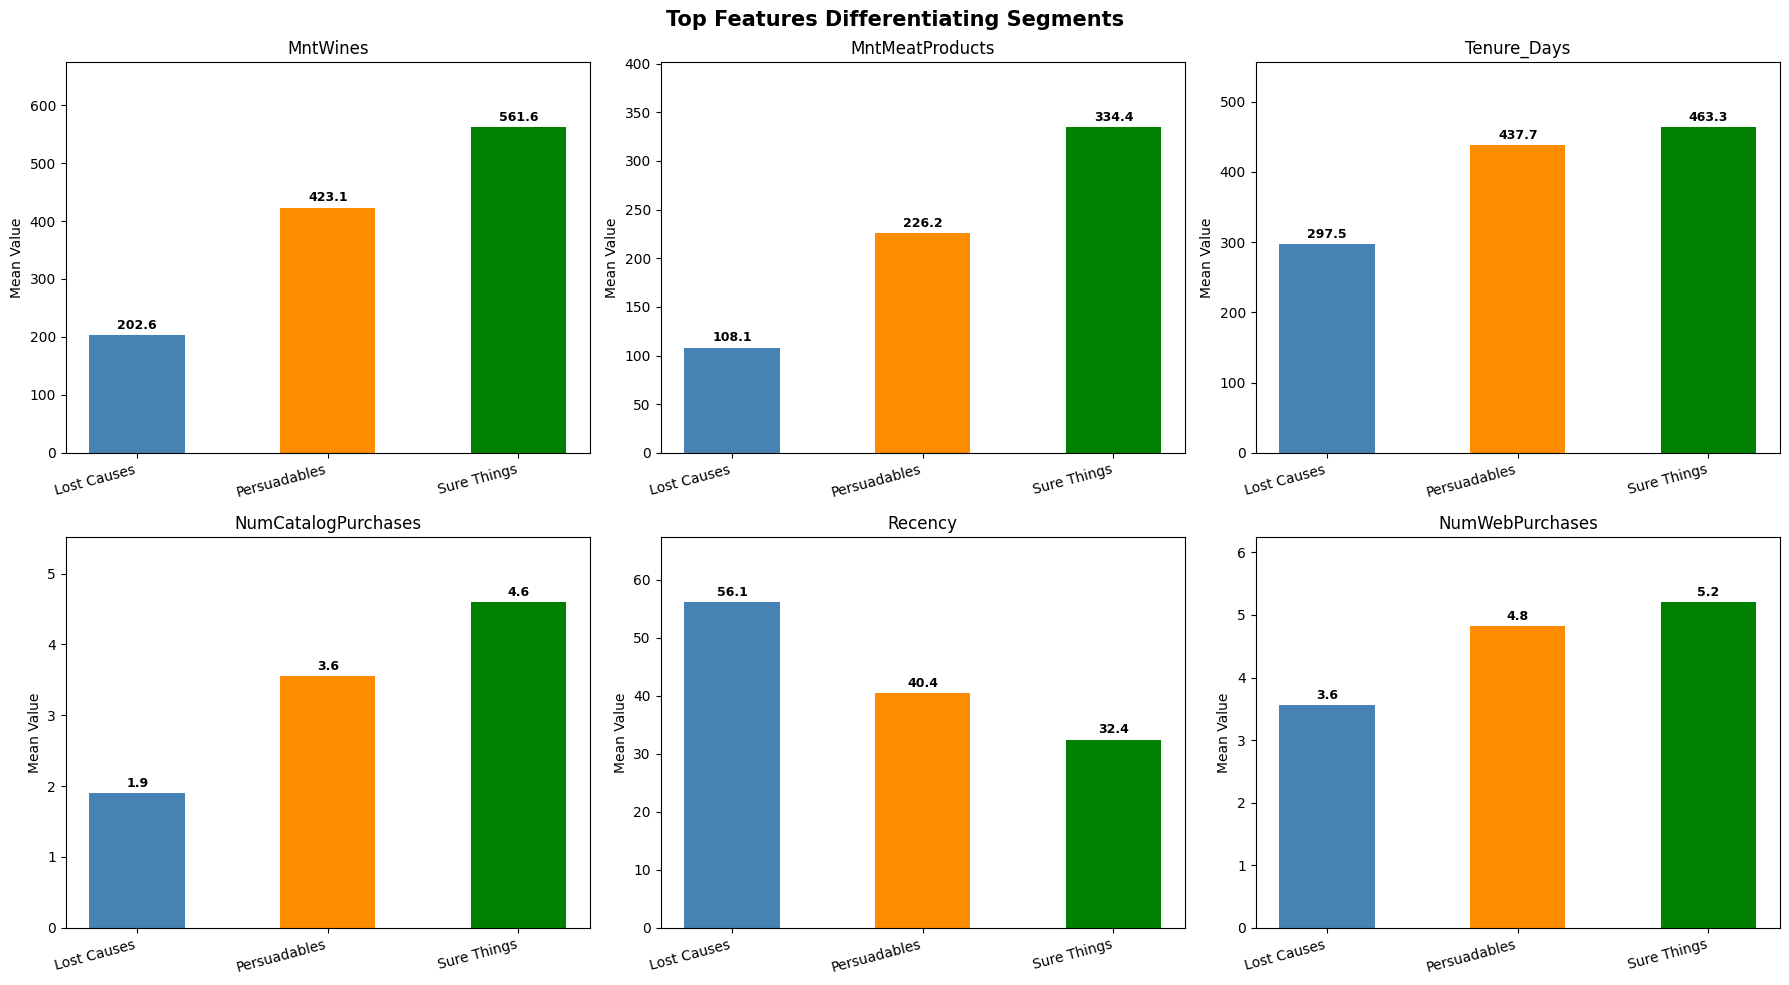


── Persuadables vs Sure Things & Lost Causes ──
                     Persuadables  Sure Things  Lost Causes P vs ST % P vs LC %
MntWines                   423.12       561.62       202.59    -24.7%   +108.9%
MntMeatProducts            226.16       334.43       108.14    -32.4%   +109.1%
Tenure_Days                437.72       463.29       297.52     -5.5%    +47.1%
NumCatalogPurchases          3.56         4.59         1.90    -22.4%    +87.4%
Recency                     40.38        32.43        56.06    +24.5%    -28.0%
NumWebPurchases              4.82         5.20         3.56     -7.3%    +35.4%


In [68]:
from scipy import stats

# ── 1. NUMERICAL FEATURES — ANOVA + EFFECT SIZE (ETA SQUARED) ────────────────

numerical_kpi = [
    'Age', 'Income', 'Tenure_Days', 'Recency',
    'MntWines', 'MntFruits','MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'Kidhome', 'Teenhome'
]

anova_results = []
for col in numerical_kpi:
    groups = [group[col].dropna().values for _, group in df.groupby('segment')]
    f_stat, p_val = stats.f_oneway(*groups)
    
    # Eta squared — effect size (how much variance is explained by segment)
    grand_mean = df[col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 
                     for g in [df[df['segment']==s][col] for s in ['Lost Causes','Persuadables','Sure Things']])
    ss_total   = ((df[col] - grand_mean)**2).sum()
    eta_sq     = ss_between / ss_total

    anova_results.append({
        'Feature':    col,
        'F-stat':     round(f_stat, 2),
        'p-value':    round(p_val, 4),
        'Eta_Squared': round(eta_sq, 4),
        'Significant': '✅' if p_val < 0.05 else '❌'
    })

anova_df = pd.DataFrame(anova_results).sort_values('Eta_Squared', ascending=False)
print("── ANOVA Results (sorted by effect size) ──")
print(anova_df.to_string(index=False))

# ── 2. CATEGORICAL FEATURES — CHI-SQUARE ─────────────────────────────────────

categorical_kpi = ['Education', 'Has_Partner', 'Kidhome', 'Teenhome']

chi2_results = []
for col in categorical_kpi:
    contingency = pd.crosstab(df['segment'], df[col])
    chi2, p_val, dof, _ = stats.chi2_contingency(contingency)
    chi2_results.append({
        'Feature':     col,
        'Chi2':        round(chi2, 2),
        'p-value':     round(p_val, 4),
        'Significant': '✅' if p_val < 0.05 else '❌'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)
print("\n── Chi-Square Results ──")
print(chi2_df.to_string(index=False))

# ── 3. PLOT TOP DIFFERENTIATING FEATURES ─────────────────────────────────────

top_features = anova_df[anova_df['Significant'] == '✅'].head(6)['Feature'].tolist()
seg_order    = ['Lost Causes', 'Persuadables', 'Sure Things']
colors       = ['steelblue', 'darkorange', 'green']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    means = [df[df['segment'] == s][feat].mean() for s in seg_order]
    bars  = axes[i].bar(seg_order, means, color=colors, width=0.5)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + max(means) * 0.01,
                     f'{bar.get_height():.1f}',
                     ha='center', va='bottom', fontweight='bold', fontsize=9)
    axes[i].set_title(f'{feat}', fontsize=12)
    axes[i].set_ylabel('Mean Value')
    axes[i].set_xticklabels(seg_order, rotation=15, ha='right')
    axes[i].set_ylim(0, max(means) * 1.2)

plt.suptitle('Top Features Differentiating Segments', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. PERSUADABLES UNIQUE PROFILE ───────────────────────────────────────────

print("\n── Persuadables vs Sure Things & Lost Causes ──")
persuadable_profile = pd.concat([
    df[df['segment'] == 'Persuadables'][top_features].mean().rename('Persuadables'),
    df[df['segment'] == 'Sure Things'][top_features].mean().rename('Sure Things'),
    df[df['segment'] == 'Lost Causes'][top_features].mean().rename('Lost Causes'),
], axis=1).round(2)

persuadable_profile['P vs ST %'] = (
    (persuadable_profile['Persuadables'] - persuadable_profile['Sure Things'])
    / persuadable_profile['Sure Things'] * 100
).round(1).map('{:+.1f}%'.format)

persuadable_profile['P vs LC %'] = (
    (persuadable_profile['Persuadables'] - persuadable_profile['Lost Causes'])
    / persuadable_profile['Lost Causes'] * 100
).round(1).map('{:+.1f}%'.format)

print(persuadable_profile.to_string())

# Second Model

              N_Customers Actual_Response  Avg_Score
segment                                             
Lost Causes          1399            0.4%      0.115
Persuadables          541           15.9%      0.480
Sure Things           300           80.7%      0.818


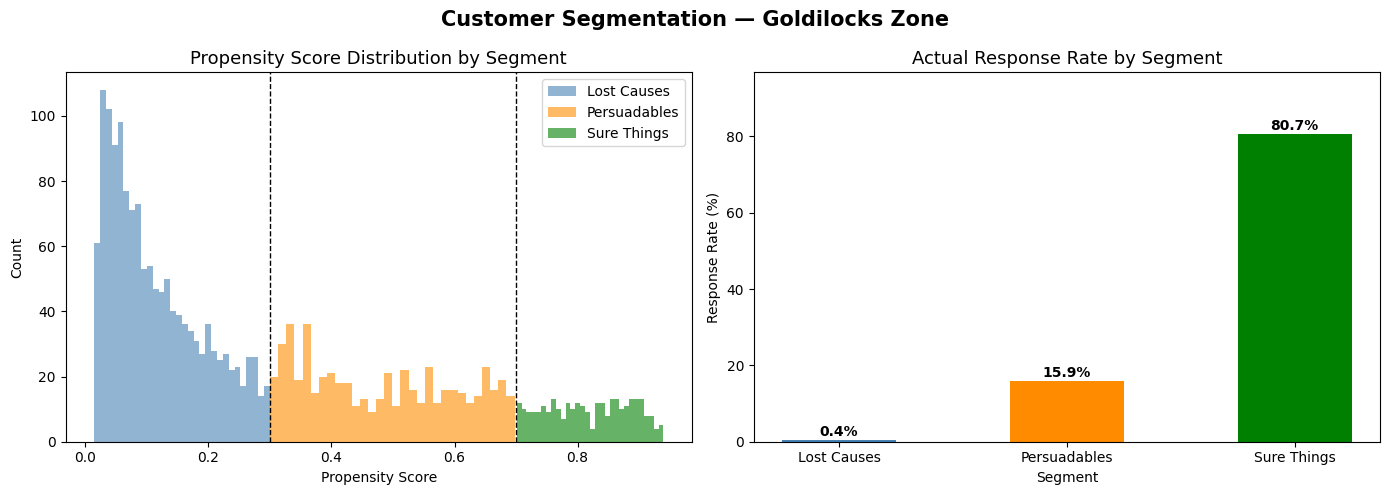

In [69]:
# ── 1. APPLY STAGE 1 MODEL TO FULL DATASET ───────────────────────────────────

df['propensity_score'] = final_model.predict_proba(X)[:, 1]

# ── 2. SEGMENT USING GOLDILOCKS THRESHOLDS ────────────────────────────────────

def assign_zone(score):
    if score < 0.3:
        return 'Lost Causes'
    elif score <= 0.7:
        return 'Persuadables'
    else:
        return 'Sure Things'

df['segment'] = df['propensity_score'].apply(assign_zone)

# ── 3. SUMMARY ────────────────────────────────────────────────────────────────

summary = df.groupby('segment').agg(
    N_Customers     = ('propensity_score', 'count'),
    Actual_Response = ('Response', 'mean'),
    Avg_Score       = ('propensity_score', 'mean'),
).round(3)
summary['Actual_Response'] = (summary['Actual_Response'] * 100).map('{:.1f}%'.format)
summary = summary.loc[['Lost Causes', 'Persuadables', 'Sure Things']]
print(summary)

# ── 4. DISTRIBUTION PLOT ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Lost Causes': 'steelblue', 'Persuadables': 'darkorange', 'Sure Things': 'green'}
for segment, group in df.groupby('segment'):
    axes[0].hist(group['propensity_score'], bins=30, alpha=0.6,
                 label=segment, color=colors[segment])
axes[0].axvline(0.3, color='black', linestyle='--', linewidth=1)
axes[0].axvline(0.7, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Propensity Score Distribution by Segment', fontsize=13)
axes[0].set_xlabel('Propensity Score')
axes[0].set_ylabel('Count')
axes[0].legend()

seg_order     = ['Lost Causes', 'Persuadables', 'Sure Things']
response_rates = df.groupby('segment')['Response'].mean() * 100
response_rates = response_rates.reindex(seg_order)
bars = axes[1].bar(seg_order, response_rates.values,
                   color=[colors[s] for s in seg_order], width=0.5)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Actual Response Rate by Segment', fontsize=13)
axes[1].set_ylabel('Response Rate (%)')
axes[1].set_xlabel('Segment')
axes[1].set_ylim(0, response_rates.max() * 1.2)

plt.suptitle('Customer Segmentation — Goldilocks Zone', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [70]:
df_stage2 = df[df['segment'].isin(['Persuadables', 'Sure Things'])].copy()

# Target: Persuadables = 1, Sure Things = 0
df_stage2['target_stage2'] = (df_stage2['segment'] == 'Persuadables').astype(int)

print(f"Stage 2 dataset size: {len(df_stage2)}")
print(f"Sure Things  (0): {(df_stage2['target_stage2'] == 0).sum()}")
print(f"Persuadables (1): {(df_stage2['target_stage2'] == 1).sum()}")

Stage 2 dataset size: 841
Sure Things  (0): 300
Persuadables (1): 541


In [77]:
drop_cols_s2 = ['Response', 'segment', 'propensity_score', 'target_stage2', 'Income_Bin','AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
             'AcceptedCmp4', 'AcceptedCmp5',
             'Z_CostContact', 'Z_Revenue', 'ID']

# drop only columns that exist
drop_cols_s2 = [c for c in drop_cols_s2 if c in df_stage2.columns]

X2 = df_stage2.drop(columns=drop_cols_s2)
y2 = df_stage2['target_stage2']

In [78]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scale_pos_weight2 = (y2_train == 0).sum() / (y2_train == 1).sum()

In [79]:
categorical_features2 = ['Education']
numerical_features2   = [c for c in X2.columns if c not in categorical_features2]

preprocessor2 = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_features2),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=[education_order],
                                   handle_unknown='use_encoded_value',
                                   unknown_value=-1))
    ]), categorical_features2)
])

In [80]:
def objective_xgb2(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight':  scale_pos_weight2,
        'eval_metric':       'aucpr',
        'use_label_encoder': False,
        'random_state':      42,
        'n_jobs':            -1
    }
    model = Pipeline([('pre', preprocessor2),
                      ('clf', XGBClassifier(**params))])
    return cross_val_score(model, X2_train, y2_train,
                           cv=cv2, scoring='average_precision', n_jobs=-1).mean()


def objective_lgbm2(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'class_weight':     'balanced',
        'random_state':     42,
        'n_jobs':           1,
        'verbose':          -1,
        'force_col_wise':   True
    }
    model = Pipeline([('pre', preprocessor2),
                      ('clf', LGBMClassifier(**params))])
    return cross_val_score(model, X2_train, y2_train,
                           cv=cv2, scoring='average_precision', n_jobs=1).mean()


def objective_cat2(trial):
    params = {
        'iterations':          trial.suggest_int('iterations', 100, 600),
        'depth':               trial.suggest_int('depth', 3, 10),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1e-4, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'scale_pos_weight':    scale_pos_weight2,
        'random_seed':         42,
        'verbose':             False
    }
    cat_idx = [X2_train.columns.get_loc('Education')]
    model   = CatBoostClassifier(**params, cat_features=cat_idx)
    scores  = cross_val_score(model, X2_train, y2_train,
                              cv=cv2, scoring='average_precision', n_jobs=-1)
    return scores.mean()


def objective_lr2(trial):
    params = {
        'C':            trial.suggest_float('C', 1e-3, 10.0, log=True),
        'penalty':      trial.suggest_categorical('penalty', ['l1', 'l2']),
        'class_weight': 'balanced',
        'solver':       'saga',
        'max_iter':     2000,
        'random_state': 42
    }
    model = Pipeline([('pre', preprocessor2),
                      ('clf', LogisticRegression(**params))])
    return cross_val_score(model, X2_train, y2_train,
                           cv=cv2, scoring='average_precision', n_jobs=-1).mean()


def objective_svm2(trial):
    params = {
        'C':            trial.suggest_float('C', 1e-2, 100.0, log=True),
        'gamma':        trial.suggest_categorical('gamma', ['scale', 'auto']),
        'kernel':       trial.suggest_categorical('kernel', ['rbf', 'poly']),
        'class_weight': 'balanced',
        'probability':  True,
        'random_state': 42
    }
    model = Pipeline([('pre', preprocessor2),
                      ('clf', SVC(**params))])
    return cross_val_score(model, X2_train, y2_train,
                           cv=cv2, scoring='average_precision', n_jobs=-1).mean()


def objective_mlp2(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers   = tuple(trial.suggest_int(f'n_units_l{i}', 32, 256) for i in range(n_layers))
    params   = {
        'hidden_layer_sizes': layers,
        'activation':         trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha':              trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'max_iter':           500,
        'random_state':       42
    }
    model = Pipeline([('pre', preprocessor2),
                      ('clf', MLPClassifier(**params))])
    return cross_val_score(model, X2_train, y2_train,
                           cv=cv2, scoring='average_precision', n_jobs=-1).mean()


In [81]:
studies2 = {
    'XGBoost':            objective_xgb2,
    'LightGBM':           objective_lgbm2,
    'CatBoost':           objective_cat2,
    'LogisticRegression': objective_lr2,
    'SVM':                objective_svm2,
    'MLP':                objective_mlp2,
}

best_params2 = {}
results2     = {}

for name, objective in studies2.items():
    print(f"\n── Tuning {name} ──")
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=50, show_progress_bar=True)
    best_params2[name] = study.best_params
    results2[name]     = study.best_value
    print(f"  Best PR-AUC: {study.best_value:.4f}")

results2_df = pd.DataFrame.from_dict(results2, orient='index', columns=['CV PR-AUC'])
results2_df = results2_df.sort_values('CV PR-AUC', ascending=False)
print("\n── Stage 2 CV Results Summary ──")
print(results2_df.round(4))


── Tuning XGBoost ──


  0%|          | 0/50 [00:00<?, ?it/s]

/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:02:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:02:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:02:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:02:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use

  Best PR-AUC: 0.9440

── Tuning LightGBM ──


/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:03:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:03:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:03:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:03:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use

...

  0%|          | 0/50 [00:00<?, ?it/s]

  Best PR-AUC: 0.9194

── Tuning MLP ──


  0%|          | 0/50 [00:00<?, ?it/s]

/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/local.hcpa.ufrgs.br/tkruger/Install/conda/miniconda3/envs/ML/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691:

  Best PR-AUC: 0.9175

── Stage 2 CV Results Summary ──
                    CV PR-AUC
LightGBM               0.9452
XGBoost                0.9440
CatBoost               0.9432
SVM                    0.9194
MLP                    0.9175
LogisticRegression     0.8600


Stage 2 — Test ROC-AUC : 0.8876
Stage 2 — Test PR-AUC  : 0.9221

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73        60
           1       0.84      0.90      0.87       109

    accuracy                           0.82       169
   macro avg       0.81      0.79      0.80       169
weighted avg       0.82      0.82      0.82       169



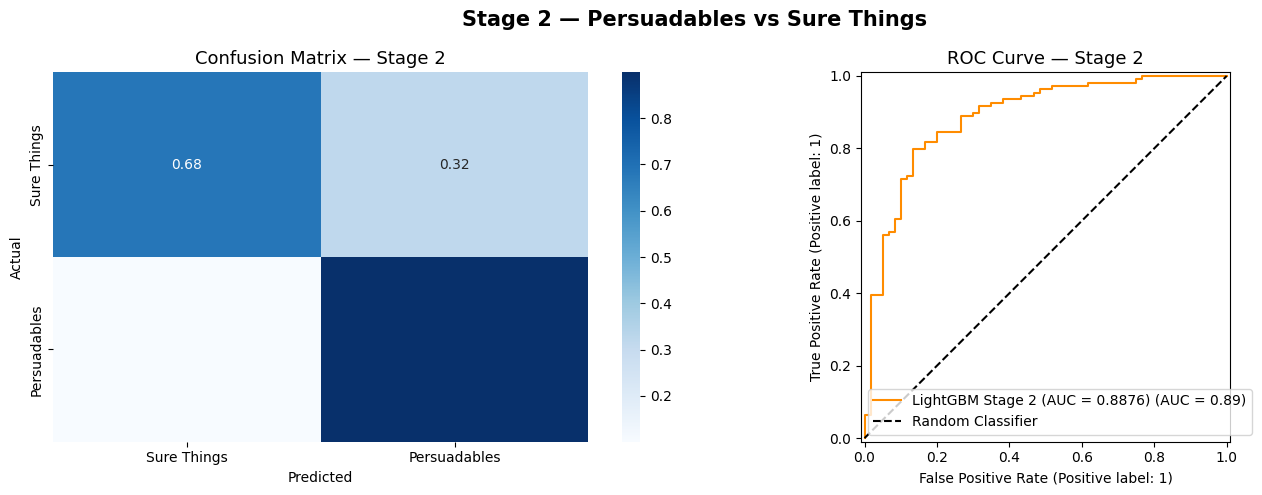

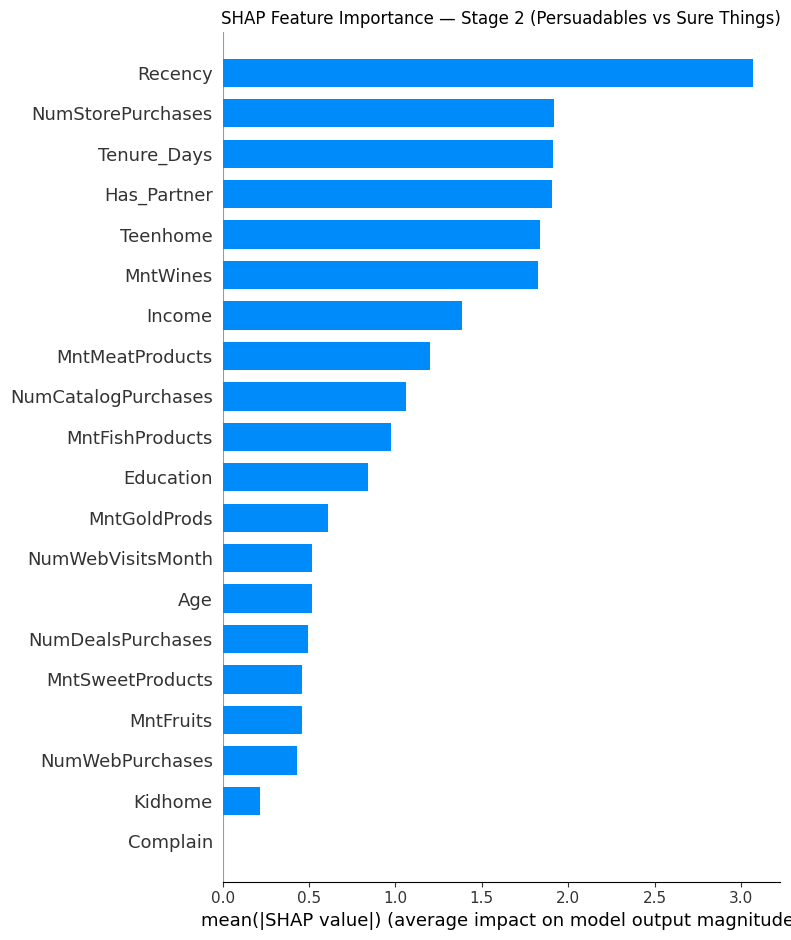

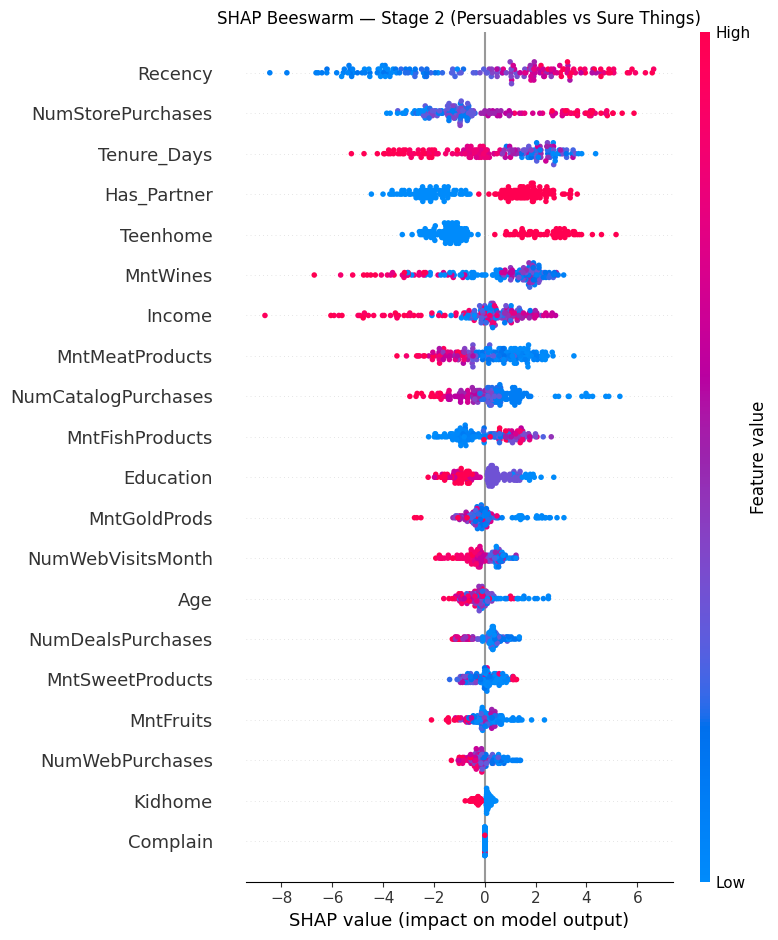

In [82]:
# ── 1. RETRAIN LGBM STAGE 2 WITH BEST PARAMS ─────────────────────────────────

best_lgbm2 = LGBMClassifier(
    **best_params2['LightGBM'],
    class_weight='balanced',
    random_state=42,
    n_jobs=1,
    verbose=-1,
    force_col_wise=True
)

final_model2 = Pipeline([('pre', preprocessor2),
                         ('clf', best_lgbm2)])

final_model2.fit(X2_train, y2_train)

# ── 2. PREDICT ────────────────────────────────────────────────────────────────

y2_pred_proba = final_model2.predict_proba(X2_test)[:, 1]
y2_pred       = final_model2.predict(X2_test)

# ── 3. METRICS ────────────────────────────────────────────────────────────────

roc_auc2 = roc_auc_score(y2_test, y2_pred_proba)
pr_auc2  = average_precision_score(y2_test, y2_pred_proba)
print(f"Stage 2 — Test ROC-AUC : {roc_auc2:.4f}")
print(f"Stage 2 — Test PR-AUC  : {pr_auc2:.4f}")
print(f"\nClassification Report:\n{classification_report(y2_test, y2_pred)}")

# ── 4. PLOTS ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm2 = confusion_matrix(y2_test, y2_pred, normalize='true')
sns.heatmap(cm2, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=['Sure Things', 'Persuadables'],
            yticklabels=['Sure Things', 'Persuadables'])
axes[0].set_title('Confusion Matrix — Stage 2', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

RocCurveDisplay.from_predictions(y2_test, y2_pred_proba, ax=axes[1],
                                  name=f'LightGBM Stage 2 (AUC = {roc_auc2:.4f})',
                                  color='darkorange')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_title('ROC Curve — Stage 2', fontsize=13)
axes[1].legend()

plt.suptitle('Stage 2 — Persuadables vs Sure Things', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. SHAP ───────────────────────────────────────────────────────────────────

fitted_preprocessor2 = final_model2.named_steps['pre']
fitted_lgbm2         = final_model2.named_steps['clf']

X2_test_transformed  = fitted_preprocessor2.transform(X2_test)
feature_names2       = numerical_features2 + categorical_features2
X2_test_shap         = pd.DataFrame(X2_test_transformed, columns=feature_names2)

explainer2   = shap.TreeExplainer(fitted_lgbm2)
shap_values2 = explainer2.shap_values(X2_test_shap)

if isinstance(shap_values2, list):
    shap_vals2 = shap_values2[1]
else:
    shap_vals2 = shap_values2

# Bar — global importance
plt.figure()
shap.summary_plot(shap_vals2, X2_test_shap, plot_type='bar',
                  feature_names=feature_names2, show=False)
plt.title('SHAP Feature Importance — Stage 2 (Persuadables vs Sure Things)')
plt.tight_layout()
plt.show()

# Beeswarm — direction and magnitude
plt.figure()
shap.summary_plot(shap_vals2, X2_test_shap,
                  feature_names=feature_names2, show=False)
plt.title('SHAP Beeswarm — Stage 2 (Persuadables vs Sure Things)')
plt.tight_layout()
plt.show()

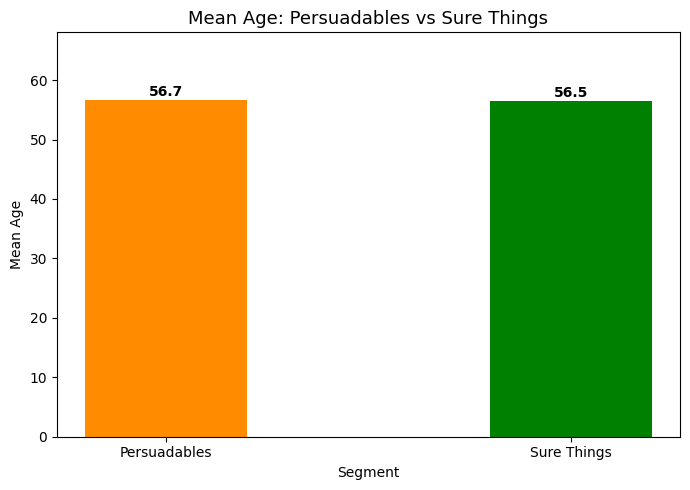

In [84]:
fig, ax = plt.subplots(figsize=(7, 5))

age_comparison = df[df['segment'].isin(['Persuadables', 'Sure Things'])] \
                   .groupby('segment')['Age'].mean()

bars = ax.bar(
    age_comparison.index,
    age_comparison.values,
    color=['darkorange', 'green'],
    width=0.4
)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Mean Age: Persuadables vs Sure Things', fontsize=13)
ax.set_ylabel('Mean Age')
ax.set_xlabel('Segment')
ax.set_ylim(0, age_comparison.max() * 1.2)

plt.tight_layout()
plt.show()

In [ ]:
""" The mean ages are similar, so are the incomes and customer habits.
The main differences that characterize persuadables are that they are married and that they have teens at home. 
This means that new campaigns should focus on married with kids middle class customers.
"""

         CAMPAIGN BUSINESS CASE — KPI SUMMARY

── Segment Sizes ──────────────────────────────────────
  Total Customers       :    2,240
  Sure Things           :      300  (13.4%)
  Persuadables          :      530  (23.7%)
  Lost Causes           :    1,399  (62.5%)

── Average Spend per Segment ──────────────────────────
  Sure Things           : $1,099.74
  Persuadables          : $  823.81
  Lost Causes           : $  415.74

── Campaign Cost per Contact  : $3.00
   Revenue per Contact       : $11.00

── Scenario A — Contact Everyone (No Model) ───────────
  Total Cost            : $  6,720.00
  Total Revenue         : $  3,674.00
  ROI                   :     -45.3%

── Scenario B — Target Persuadables Only (Model) ──────
  Total Cost            : $  1,590.00
  Total Revenue         : $  5,830.00
  Incremental Revenue   : $  4,240.00
  ROI                   :     266.7%

── Model Lift ─────────────────────────────────────────
  Baseline Response Rate:     14.9%
  Persuadable Res

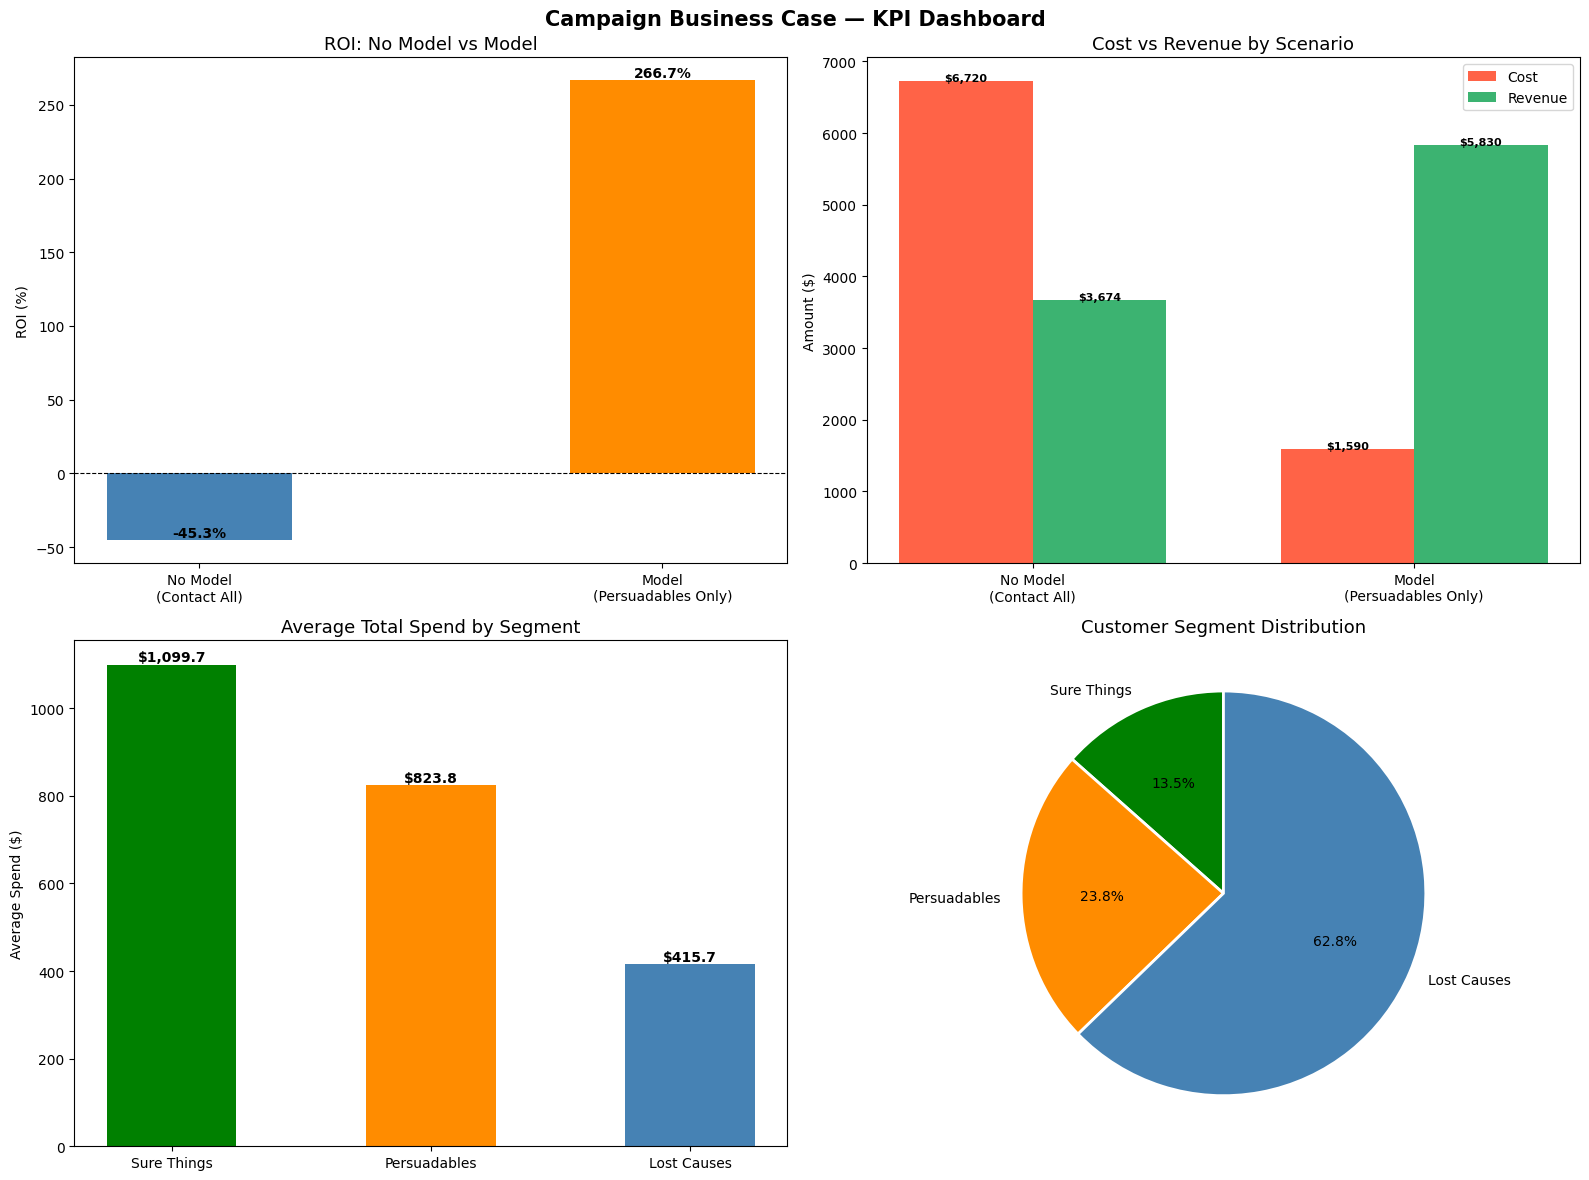

In [83]:
# ── 0. CONSTANTS ──────────────────────────────────────────────────────────────

COST_PER_CONTACT = df['Z_CostContact'].iloc[0]  # constant value from dataset
REVENUE_PER_CONTACT = df['Z_Revenue'].iloc[0]    # constant value from dataset

# ── 1. APPLY STAGE 2 TO ALL PERSUADABLES ─────────────────────────────────────

df_persuadables = df[df['segment'] == 'Persuadables'].copy()

drop_cols_s2 = ['Response', 'segment', 'propensity_score', 'target_stage2', 'Income_Bin']
drop_cols_s2 = [c for c in drop_cols_s2 if c in df_persuadables.columns]

X_persuadables = df_persuadables.drop(columns=drop_cols_s2)

df_persuadables['persuadable_proba'] = final_model2.predict_proba(X_persuadables)[:, 1]
df_persuadables['predicted_persuadable'] = final_model2.predict(X_persuadables)

# ── 2. REVENUE ESTIMATION ─────────────────────────────────────────────────────

mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df_persuadables['TotalSpend'] = df_persuadables[mnt_cols].sum(axis=1)

# Segments for analysis
true_persuadables  = df_persuadables[df_persuadables['predicted_persuadable'] == 1]
sure_things        = df[df['segment'] == 'Sure Things'].copy()
sure_things['TotalSpend'] = sure_things[mnt_cols].sum(axis=1)
lost_causes        = df[df['segment'] == 'Lost Causes'].copy()
lost_causes['TotalSpend'] = lost_causes[mnt_cols].sum(axis=1)

# Core numbers
n_persuadables        = len(true_persuadables)
n_sure_things         = len(sure_things)
n_lost_causes         = len(lost_causes)
n_total               = len(df)

avg_spend_persuadable = true_persuadables['TotalSpend'].mean()
avg_spend_sure_things = sure_things['TotalSpend'].mean()
avg_spend_lost        = lost_causes['TotalSpend'].mean()

# Scenario: contact only Persuadables
cost_target_only      = n_persuadables * COST_PER_CONTACT
revenue_target_only   = n_persuadables * REVENUE_PER_CONTACT
incremental_revenue   = revenue_target_only - cost_target_only
roi_target            = (revenue_target_only - cost_target_only) / cost_target_only * 100

# Scenario: contact everyone (baseline — no model)
cost_all              = n_total * COST_PER_CONTACT
revenue_all           = df['Response'].sum() * REVENUE_PER_CONTACT
roi_all               = (revenue_all - cost_all) / cost_all * 100

# Lift
baseline_response     = df['Response'].mean()
persuadable_response  = true_persuadables['Response'].mean() if 'Response' in true_persuadables.columns else None
lift                  = persuadable_response / baseline_response if persuadable_response else None

# ── 3. KPI SUMMARY TABLE ──────────────────────────────────────────────────────

print("=" * 55)
print("         CAMPAIGN BUSINESS CASE — KPI SUMMARY")
print("=" * 55)

print(f"\n── Segment Sizes ──────────────────────────────────────")
print(f"  Total Customers       : {n_total:>8,}")
print(f"  Sure Things           : {n_sure_things:>8,}  ({n_sure_things/n_total*100:.1f}%)")
print(f"  Persuadables          : {n_persuadables:>8,}  ({n_persuadables/n_total*100:.1f}%)")
print(f"  Lost Causes           : {n_lost_causes:>8,}  ({n_lost_causes/n_total*100:.1f}%)")

print(f"\n── Average Spend per Segment ──────────────────────────")
print(f"  Sure Things           : ${avg_spend_sure_things:>8,.2f}")
print(f"  Persuadables          : ${avg_spend_persuadable:>8,.2f}")
print(f"  Lost Causes           : ${avg_spend_lost:>8,.2f}")

print(f"\n── Campaign Cost per Contact  : ${COST_PER_CONTACT:.2f}")
print(f"   Revenue per Contact       : ${REVENUE_PER_CONTACT:.2f}")

print(f"\n── Scenario A — Contact Everyone (No Model) ───────────")
print(f"  Total Cost            : ${cost_all:>10,.2f}")
print(f"  Total Revenue         : ${revenue_all:>10,.2f}")
print(f"  ROI                   : {roi_all:>9.1f}%")

print(f"\n── Scenario B — Target Persuadables Only (Model) ──────")
print(f"  Total Cost            : ${cost_target_only:>10,.2f}")
print(f"  Total Revenue         : ${revenue_target_only:>10,.2f}")
print(f"  Incremental Revenue   : ${incremental_revenue:>10,.2f}")
print(f"  ROI                   : {roi_target:>9.1f}%")

print(f"\n── Model Lift ─────────────────────────────────────────")
print(f"  Baseline Response Rate: {baseline_response*100:>8.1f}%")
if persuadable_response:
    print(f"  Persuadable Response  : {persuadable_response*100:>8.1f}%")
    print(f"  Lift                  : {lift:>8.2f}x")

print(f"\n── Cost Savings vs Blind Campaign ─────────────────────")
saved_contacts = n_total - n_persuadables
saved_cost     = saved_contacts * COST_PER_CONTACT
print(f"  Contacts Avoided      : {saved_contacts:>8,}")
print(f"  Cost Saved            : ${saved_cost:>10,.2f}")
print("=" * 55)

# ── 4. VISUALIZATIONS ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ROI Comparison
scenarios = ['No Model\n(Contact All)', 'Model\n(Persuadables Only)']
rois      = [roi_all, roi_target]
colors_roi = ['steelblue', 'darkorange']
bars = axes[0, 0].bar(scenarios, rois, color=colors_roi, width=0.4)
for bar, v in zip(bars, rois):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0, 0].set_title('ROI: No Model vs Model', fontsize=13)
axes[0, 0].set_ylabel('ROI (%)')
axes[0, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Cost vs Revenue per scenario
x       = np.arange(2)
width   = 0.35
costs   = [cost_all, cost_target_only]
revs    = [revenue_all, revenue_target_only]
axes[0, 1].bar(x - width/2, costs, width, label='Cost',    color='tomato')
axes[0, 1].bar(x + width/2, revs,  width, label='Revenue', color='mediumseagreen')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(scenarios)
axes[0, 1].set_title('Cost vs Revenue by Scenario', fontsize=13)
axes[0, 1].set_ylabel('Amount ($)')
axes[0, 1].legend()
for i, (c, r) in enumerate(zip(costs, revs)):
    axes[0, 1].text(i - width/2, c + 1, f'${c:,.0f}', ha='center', fontsize=8, fontweight='bold')
    axes[0, 1].text(i + width/2, r + 1, f'${r:,.0f}', ha='center', fontsize=8, fontweight='bold')

# Average spend by segment
seg_labels  = ['Sure Things', 'Persuadables', 'Lost Causes']
seg_spends  = [avg_spend_sure_things, avg_spend_persuadable, avg_spend_lost]
seg_colors  = ['green', 'darkorange', 'steelblue']
bars = axes[1, 0].bar(seg_labels, seg_spends, color=seg_colors, width=0.5)
for bar in bars:
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1,
                    f'${bar.get_height():,.1f}',
                    ha='center', va='bottom', fontweight='bold')
axes[1, 0].set_title('Average Total Spend by Segment', fontsize=13)
axes[1, 0].set_ylabel('Average Spend ($)')

# Segment size distribution
seg_sizes = [n_sure_things, n_persuadables, n_lost_causes]
axes[1, 1].pie(seg_sizes, labels=seg_labels, colors=seg_colors,
               autopct='%1.1f%%', startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1, 1].set_title('Customer Segment Distribution', fontsize=13)

plt.suptitle('Campaign Business Case — KPI Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()